<a href="https://colab.research.google.com/github/rizkiismail9a/data-science-2026-unsia/blob/main/pertemuan_4_MuhamadRizkiIsmail_240401010126_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#------------------------#
# Nama: Muhamad Rizki Ismail
# NIM: 240401010126
# Kelas: IF401
# Mata Kuliah: Data Science
#------------------------#

# LATIHAN dan Explorasi

import seaborn as sns

# sns.load_dataset akan memuat dataset iris secara online dari repository seaborn.
# Jika file csv iris tersedia di repo pribadi, jangan pakai sns.load_dataset, pakai saja pandas read_csv
df = sns.load_dataset('iris')
print(df)
print(df.describe().round(3))

# Mean satu kolom
print(f'Mean sepal_length: {df["sepal_length"].mean():.3f}')

# Mean semua kolom numerik
print(f'Mean semau kolom numerik: {df.select_dtypes(include='number').mean().round(3)}')

# Median
medianSepalLength = df['sepal_length'].median()
meanSepalLength = df['sepal_length'].mean()
diff = abs(meanSepalLength - medianSepalLength)

print(f'Selisih mean dan median: {diff:.2f}')

# Modus data numerik
# method mode() dapat menghasilkan multiple nilai, jika ada dua modus, ia akan memberikan dua value
print(df.select_dtypes(include='number').mode())

# Varians
col = df['sepal_length']

print(f'Varians (sampel) : {col.var():.4f}')
print(f'Varians (populasi) : {col.var(ddof=0):.4f}')

# Standar Deviasi
print(f'Standar Deviasi (sampel) : {col.std():.4f}')
print(f'Standar Deviasi (populasi) : {col.std(ddof=0):.4f}')

# Kuartil, Persentil, dan IQR (Interquartil Range)
Q1 = col.quantile(0.25)
Q2 = col.quantile(0.50)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

# Deteksi outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Me-return series
outliers = col[(col < lower) | (col > upper)]
print(f'Outliers: {outliers}')

       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100        1.800
max           7.900        4.400         6.900        2.500


In [ ]:
# Periksa jumlah nilai NaN di setiap kolom numerik
print('Jumlah NaN di setiap kolom numerik:')
print(df.select_dtypes(include='number').isnull().sum())

Jumlah NaN di setiap kolom numerik:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


In [ ]:
# Distribusi Data

import seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')

col = df['sepal_length']

print(f'Skewness : {col.skew():.3f}')
print(f'Kurtosis : {col.kurt():.3f}') # Excess kurtosis, normal ≈ 0

# Uji statistik dengan SciPy
# sintaks ini mirip di JS const {a as skew, b as pVal} = methodABC()
skew_stat, p = stats.skewtest(col)
# print(stats.skewtest(col))

print(f'Skewness test: stat={skew_stat:.3f}, p={p:.4f}')

Skewness test: stat=1.596, p=0.1104


Berikut adalah plot distribusi untuk `sepal_length`. Histogram menunjukkan frekuensi setiap rentang nilai, dan garis KDE (Kernel Density Estimate) adalah perkiraan kepadatan probabilitas data. Dari plot ini, Anda dapat secara visual mengkonfirmasi skewness data.

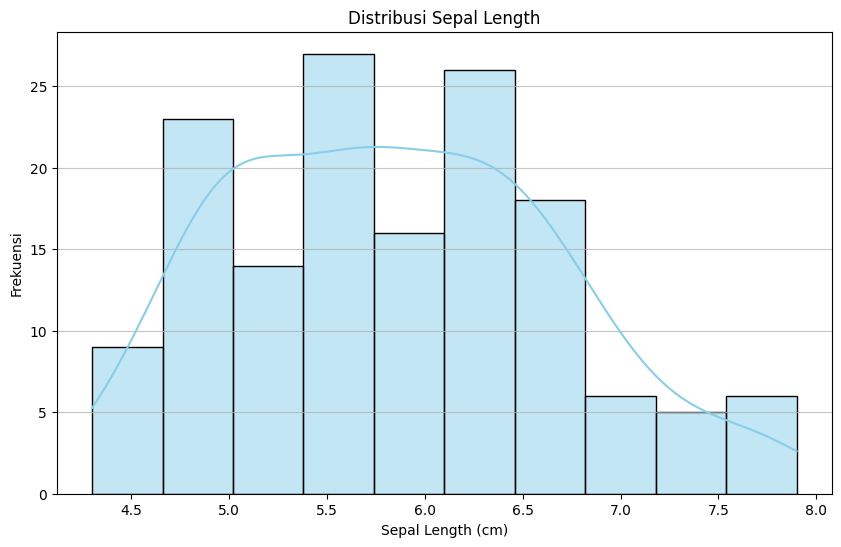

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(col, kde=True, bins=10, color='skyblue')
plt.title('Distribusi Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Analisis Univariat**

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Kode ini menggunakan library matplotlib.pyplot (yang biasanya di-alias sebagai plt) untuk membuat gambar (figure) dan satu set subplot di dalamnya. Mari kita pecah:

  plt.subplots(): Ini adalah fungsi yang serbaguna untuk membuat gambar sekaligus satu atau lebih subplot.

  1, 2: Argumen pertama (1) menentukan jumlah baris subplot, dan argumen kedua (2) menentukan jumlah kolom subplot. Jadi, kode ini membuat tata letak dengan 1 baris dan 2 kolom, artinya ada dua subplot yang akan dibuat berdampingan.
  figsize=(12, 5): Ini adalah argumen opsional yang mengatur ukuran keseluruhan dari gambar (fig) yang dibuat. Ukurannya diberikan dalam inci, di mana 12 adalah lebar dan 5 adalah tinggi.

  fig: Variabel ini akan menampung objek Figure dari Matplotlib. Ini adalah "kanvas" utama tempat semua plot, sumbu, judul, dll., akan digambar.
  
  axes: Variabel ini akan menampung objek Axes (atau array dari objek Axes jika ada lebih dari satu subplot). Setiap objek Axes adalah area plotting individual di dalam gambar. Karena kita meminta 1 baris dan 2 kolom, axes akan menjadi array (atau list) yang berisi dua objek Axes, satu untuk setiap subplot. Anda akan menggunakan objek-objek ini untuk membuat plot yang sebenarnya (misalnya, axes[0].plot(...), axes[1].hist(...)).


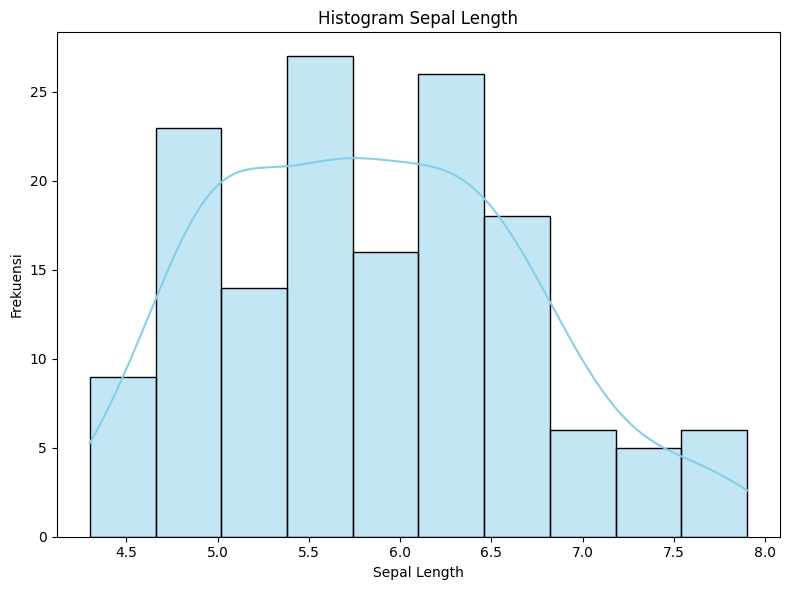

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('iris')

# subplots(jumlah baris, jumlah kolom, figsize=(lebar Inci, tinggi Inci))
# axes bisa menampung lebih dari satu object
# fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Baris ini menciptakan 2 subplot

# Jika hanya ingin 1 histogram, buat saja 1 figur dan plot langsung ke situ
plt.figure(figsize=(8, 6)) # Buat figur baru dengan ukuran yang sesuai

# Histogram dasar
# bins itu jumlah interval, bins=10 artinya dibagi menjadi 10 rentang
sns.histplot(df['sepal_length'], bins=10, color='skyblue', kde=True) # Plot langsung ke figur
plt.title('Histogram Sepal Length') # Set judul untuk plot tunggal
plt.xlabel('Sepal Length')
plt.ylabel('Frekuensi')
# axes[0].hist(df['sepal_length'], bins=10, color='skyblue') # Ini untuk subplot pertama
# axes[0].set_title('Histogram Sepal Length') # Ini untuk subplot pertama

# # Histogram + KDE per spesies (dikomentari karena user hanya ingin 1 plot)
# # sns.histplot(data=df, x='sepal_length', hue='species',
# # kde=True, palette='Set2', alpha=0.6, ax=axes[1]) # Ini untuk subplot kedua
# # axes[1].set_title('Distribusi per Spesies') # Ini untuk subplot kedua

plt.tight_layout() # Sesuaikan layout
plt.show() # Tampilkan plot

**Aktivitas Hands-on: Eksplorasi Statistik Dataset Iris**

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

# Inpspect Data
df = sns.load_dataset('iris')
print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

In [8]:
# Statistic deskriptif
import seaborn as sns

df = sns.load_dataset('iris')

for col_name in df.select_dtypes(include='number').columns:
  col = df[col_name]
  print(f'\n=== {col_name} ===')
  print(f' Mean : {col.mean():.3f}')
  print(f' Median : {col.median():.3f}')
  print(f' Std Dev : {col.std():.3f}')
  print(f' Skewness : {col.skew():.3f}')
  print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


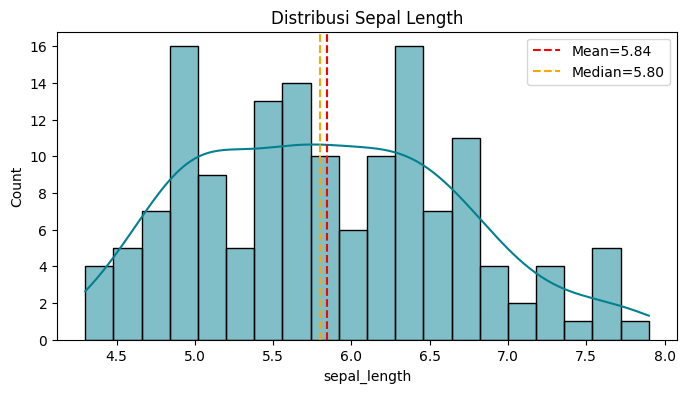

In [12]:
# Analisis Distribusi

import matplotlib.pyplot as plt, seaborn as sns

df = sns.load_dataset('iris')

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length');
ax.legend();
plt.show()

Boxplot (atau diagram kotak-garis) adalah cara standar untuk menampilkan distribusi data numerik dan skewness-nya melalui kuartil. Berikut adalah komponen-komponen utamanya:

    Kotak (Box):
        Garis tengah di dalam kotak adalah Median (Q2), yang membagi data menjadi dua bagian yang sama (nilai tengah).
        Bagian bawah kotak adalah Kuartil Pertama (Q1), yang 25% data berada di bawahnya.
        Bagian atas kotak adalah Kuartil Ketiga (Q3), yang 75% data berada di bawahnya.
        Tinggi kotak mewakili Interquartile Range (IQR), yaitu Q3 - Q1. IQR menunjukkan sebaran data di 50% bagian tengah.

    Garis (Whiskers):
        Garis yang memanjang dari kotak (sering disebut "whiskers") biasanya menunjukkan rentang data dalam 1.5 kali IQR dari tepi kotak. Artinya, whisker bawah memanjang hingga Q1 - 1.5 * IQR dan whisker atas hingga Q3 + 1.5 * IQR (tetapi tidak lebih jauh dari nilai minimum/maksimum data aktual).

    Titik (Outliers):
        Titik-titik individual di luar batas whiskers biasanya dianggap sebagai outlier atau pencilan, yaitu nilai data yang sangat berbeda dari sebagian besar data lainnya.

/tmp/ipykernel_1282/3445532276.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_1282/3445532276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


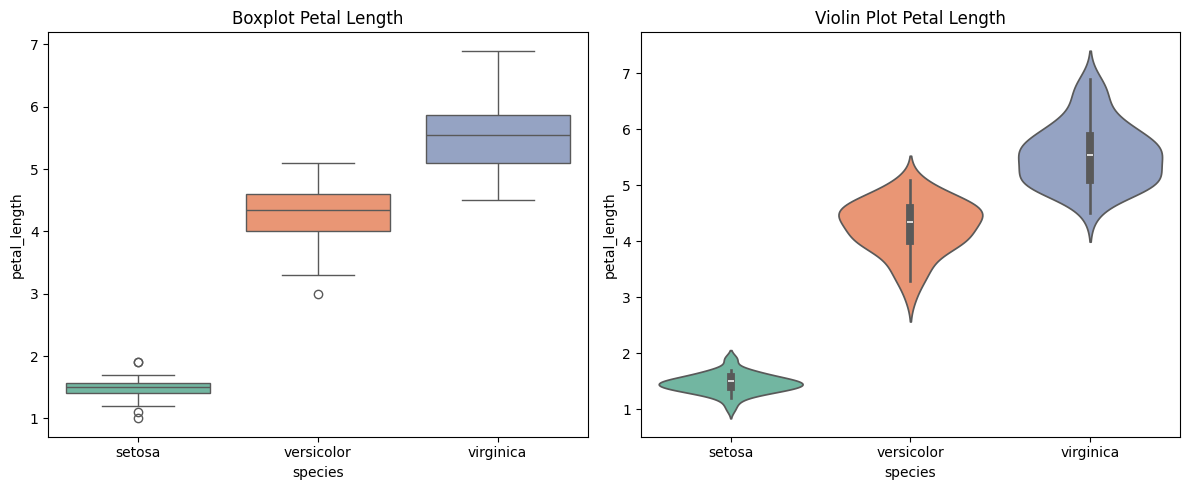

In [13]:
# Boxplot per Spesies
import matplotlib.pyplot as plt, seaborn as sns

df = sns.load_dataset('iris')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout();
plt.show()

In [16]:
# Matriks Korelasi Pearson
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np

df = sns.load_dataset('iris')

# buang kolom species karena korelasi hanya bisa menghitung numerik
corr = df.drop('species', axis=1).corr(method='pearson')
print('Matriks korelasi antarkolom')
print(corr.round(3))

print('#-----------------------#')

# mengabaikan duplikasi dalam matriks korelasi
mask = np.triu(np.ones(corr.shape, dtype=bool))

# mengisolasi hanya bagian segitiga bawah
corr_masked = corr.where(~mask)

# Baris ini menemukan pasangan kolom (indeks multi-level) yang memiliki nilai korelasi Pearson tertinggi
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

Table korelasi antarkolom
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
#-----------------------#
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


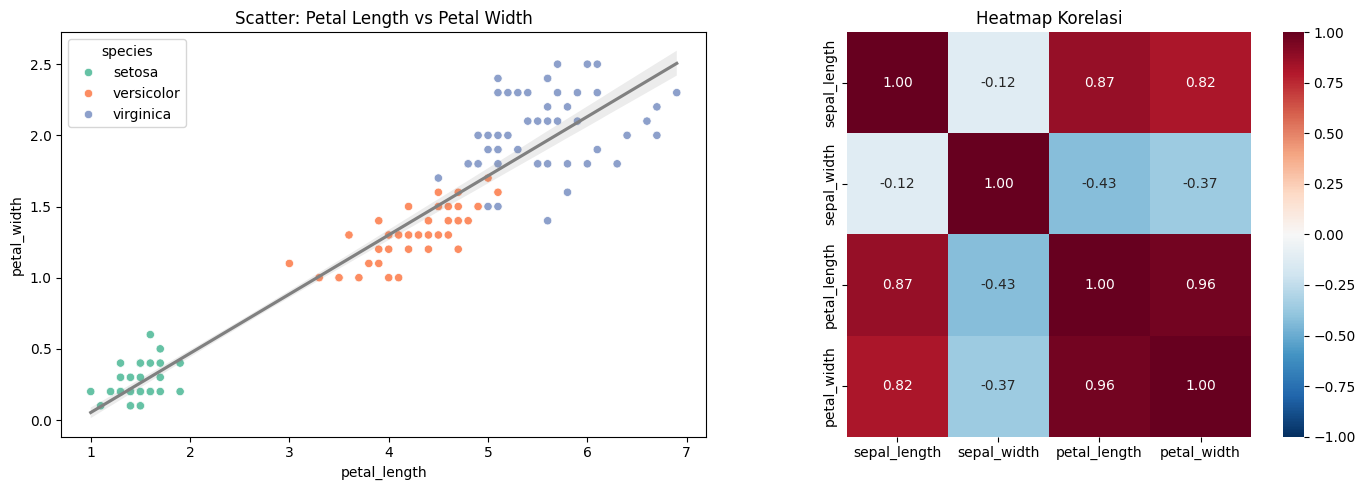

In [17]:
# Scatter Plot & Heatmap
import matplotlib.pyplot as plt, seaborn as sns

df = sns.load_dataset('iris')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()